In [1]:
import collections
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.notebook import tqdm

random.seed(1234)
np.random.seed(1234)
torch.manual_seed(1234)
print("numpy: ", np.__version__)
print("torch: ", torch.__version__)

numpy:  2.0.2
torch:  2.9.0+cpu


In [2]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MAX_INVENTORY = 100
MAX_STEP_COUNT = 31
INITIAL_STATE = np.array([MAX_INVENTORY / MAX_INVENTORY,
                          MAX_STEP_COUNT / MAX_STEP_COUNT],  # 状態(観察)は[残り在庫の割合, 残りステップの割合]で表現する
                         dtype=np.float32)
PRICE_MIN = 100
PRICE_MAX = 180
ACTION_DIM = 1  # 1ステップで取り得る行動の数 # 本件は価格を1つ選択する行動なので1になる
REPLAY_BUFFER_MAX_SIZE = 50000
UPDATE_MODEL_BATCH_SIZE = 64
GAMMA = 0.98  # 割引率
ALPHA = 0.9
TAU = 0.005  # ターゲットCriticのパラメータを更新する時の学習率
UPDATE_CRITIC_TIMES = 2
MBPO_STEP_PER_EPISODE = 5  # MBPOモデルでの経験データ取得は1エピソード毎に何回か # 明示的に指定しないとdoneフラグにならなくて実質無限ループになる

In [3]:
class PriceEnvironment():
    def __init__(self, max_inventory, max_step_count, price_min, price_max):
        self.max_inventory = max_inventory
        self.inventory = self.max_inventory
        self.max_step_count = max_step_count
        self.step_count = 0
        self.price_min = price_min
        self.price_max = price_max

    def step(self, continuous_action):
        price = self.price_min + (self.price_max - self.price_min) * ((continuous_action + 1) / 2)  # price_min～price_maxでの連続値 # continuous_actionはtanhの結果で-1～1の想定
        price = round(number=price,  # 1の桁を四捨五入して連続値のpriceを10刻みに量子化する
                      ndigits=-1)
        price = np.clip(a=price,  # 1の桁の四捨五入でprice_minを下回ったり、price_maxを上回ったりする事を考慮してnp.clipで範囲内の収める
                        a_min=self.price_min,
                        a_max=self.price_max)
        demand_expectation = int((self.price_max / price) * (self.inventory * 0.05))  # 「在庫の5%」×「重み」を「需要の期待値」とする # 「重み」は、最高価格に対する価格の割合の逆数(価格が高いと重みは小さい)とする
        demand = np.random.poisson(lam=demand_expectation,  # 「需要の期待値」を「ポアソン分布の期待値」として、ポアソン分布から「需要」を確率的に得る
                                   size=None)  # 引数sizeをNoneにする事でポアソン分布から1個だけの値を確率的に得る # sizeを100にすると100個の値を確率的に得る形になる
        saled_inventory = min(self.inventory, max(demand, 0))  # 「売れた在庫」は、「需要」と「在庫数」の小さい方の値とする # 「在庫数」以上の「需要」は売れないため
        reward = price * saled_inventory
        self.inventory = self.inventory - saled_inventory
        inventory_ratio = self.inventory / self.max_inventory
        self.step_count = self.step_count + 1
        step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        if self.inventory <= 0 or self.step_count >= self.max_step_count:
            done = True
        else:
            done = False
        next_state = np.array([inventory_ratio, step_ratio],
                              dtype=np.float32)
        return reward, next_state, done

    def reset(self):
        self.inventory = self.max_inventory
        self.step_count = 0
        initial_inventory_ratio = self.inventory / self.max_inventory
        initial_step_ratio = (self.max_step_count - self.step_count) / self.max_step_count
        initial_state = np.array([initial_inventory_ratio, initial_step_ratio],
                                 dtype=np.float32)
        done = False
        return initial_state, done

In [4]:
class MyStateTransitionModel(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim + action_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=state_dim)

    def forward(self, in_data_state_tensor, in_data_action_tensor):
        in_data = torch.cat(tensors=[in_data_state_tensor, in_data_action_tensor],
                            dim=1)
        out_layer_1 = torch.nn.functional.relu(self.layer_1(in_data))
        out_layer_2 = self.layer_2(out_layer_1)
        return out_layer_2


class MyRewardModel(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim + action_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=1)

    def forward(self, in_data_state_tensor, in_data_action_tensor):
        in_data = torch.cat(tensors=[in_data_state_tensor, in_data_action_tensor],
                            dim=1)
        out_layer_1 = torch.nn.functional.relu(self.layer_1(in_data))
        out_layer_2 = self.layer_2(out_layer_1)
        return out_layer_2


class MyActor(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim,
                                       out_features=64)
        self.layer_2_mu = torch.nn.Linear(in_features=64,
                                          out_features=action_dim)  # 確率分布は行動毎になるので、行動毎のmuを出力する
        self.layer_2_log_sigma = torch.nn.Linear(in_features=64,
                                                 out_features=action_dim)  # 確率分布は行動毎になるので、行動毎のlog_sigmaを出力する

    def forward(self, in_data):
        out_layer_1 = torch.nn.functional.relu(self.layer_1(in_data))
        out_layer_2_mu = self.layer_2_mu(out_layer_1)
        out_layer_2_log_sigma = self.layer_2_log_sigma(out_layer_1)
        return out_layer_2_mu, out_layer_2_log_sigma

    def get_action(self, in_data_state_tensor):
        mu, log_sigma = self.forward(in_data=in_data_state_tensor)
        log_sigma = torch.clamp(input=log_sigma,  # 論文ではlogσを発散させないために-20～2でクリッピングしている
                                min=-20,
                                max=2)
        sigma = torch.exp(log_sigma)  # sigmaを必ずプラスの値にするために、ニューラルネットワークモデルからの出力はlog_sigmaとして、それにexpを行ってsigmaにする
        epsilon = torch.randn_like(sigma)  # reparameterization trickでepsilonに掛けるのはsigmaなので、sigmaを引数にしてepsilonを作れば確実に同じ次元になる
        sampling = mu + sigma * epsilon  # Actorが出力したmuとsigmaの正規分布からのサンプリング # reparameterization trick
        continuous_action = torch.tanh(sampling)  # SACでは取り得る行動は-1～1の連続値とする
        policy = torch.distributions.Normal(loc=mu,  # Actorが出力したmuとsigmaで正規分布を作成(方策π(S)になる)
                                            scale=sigma)
        sampling_log_prob = policy.log_prob(value=sampling)  # logπ(A|S)
        continuous_action_log_prob = sampling_log_prob - torch.log(1 - continuous_action.pow(2) + 1e-6)  # samplingでの確率をtanh(sampling)での確率とみなすためにlogπ(A|S)をヤコビアン補正する
        continuous_action_log_prob_scalar = continuous_action_log_prob.sum(dim=-1,  # 行動が複数の場合は多次元ベクトルになって損失値計算で扱えないので、同時確率にしてスカラー値にするにあたり、
                                                                           keepdim=True)  # 行動毎の確率分布は独立なので同時確率は総積になるところ、logにしているので総和になる
        return continuous_action, continuous_action_log_prob_scalar


class MyCritic(torch.nn.Module):
    def __init__(self, state_dim, action_dim):  # Soft Actor CriticではCriticは行動価値を出力する形になる
        super().__init__()
        self.layer_1 = torch.nn.Linear(in_features=state_dim + action_dim,
                                       out_features=64)
        self.layer_2 = torch.nn.Linear(in_features=64,
                                       out_features=1)

    def forward(self, in_data_state, in_data_action):
        in_data = torch.cat(tensors=[in_data_state, in_data_action],
                            dim=1)
        out_layer_1 = torch.nn.functional.relu(self.layer_1(in_data))
        out_layer_2 = self.layer_2(out_layer_1)
        return out_layer_2


class MyDoubleCritic(torch.nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.critic_model_1 = MyCritic(state_dim=state_dim,
                                       action_dim=action_dim)
        self.critic_model_2 = MyCritic(state_dim=state_dim,
                                       action_dim=action_dim)

    def forward(self, in_data_state_tensor, in_data_action_tensor):
        out_critic_model_1 = self.critic_model_1(in_data_state=in_data_state_tensor,
                                                 in_data_action=in_data_action_tensor)
        out_critic_model_2 = self.critic_model_2(in_data_state=in_data_state_tensor,
                                                 in_data_action=in_data_action_tensor)
        return out_critic_model_1, out_critic_model_2

In [5]:
class ReplayBuffer():
    def __init__(self, max_queue_size):
        self.replay_buffer = collections.deque(maxlen=max_queue_size)

    def __len__(self):
        return len(self.replay_buffer)

    def add_data(self, state, action, reward, next_state, done, is_mbpo):
        data = (state, action, reward, next_state, done, is_mbpo)
        self.replay_buffer.append(data)  # タプルを1要素として経験バッファ(deque)に保存する

    def get_batch_data(self, batch_size, use_only_mbpo_data=None, use_only_real_data=None):
        datas = []
        for data in self.replay_buffer:
            if use_only_mbpo_data == True:
                if data[5] == True:
                    datas.append(data)
            elif use_only_real_data == True:
                if data[5] == False:
                    datas.append(data)
            else:
                datas.append(data)
        batch_data_list = random.sample(population=datas,  # datasからbatch_sizeの数だけランダムに要素を取り出す
                                        k=batch_size)  # 取り出した結果は、要素はタプルの形のリストになる
        state_tuple, action_tuple, reward_tuple, next_state_tuple, done_tuple, _ = zip(*batch_data_list)  # zipは縦方向でデータをタプルに纏める
        state_array = np.array(state_tuple)
        action_array = np.array(action_tuple)
        reward_array = np.array(reward_tuple)
        next_state_array = np.array(next_state_tuple)
        done_array = np.array(done_tuple)
        return state_array, action_array, reward_array, next_state_array, done_array

In [6]:
def update_state_transition_model(replay_buffer, batch_size):
    state, action, _, next_state, _ = replay_buffer.get_batch_data(batch_size=batch_size,
                                                                   use_only_real_data=True)
    state_tensor = torch.Tensor(state).squeeze(dim=1)  # (バッチ数N, 2)
    action_tensor = torch.Tensor(action).unsqueeze(dim=1)  # (バッチ数N, 1)
    predicted_next_state_tensor = nn_state_transition_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                            in_data_action_tensor=action_tensor.to(DEVICE))
    next_state_tensor = torch.Tensor(next_state).squeeze(dim=1)  # (バッチ数N, 2)
    loss_state_transition_model = state_transition_model_loss_f(input=predicted_next_state_tensor.to("cpu"),
                                                                target=next_state_tensor)
    state_transition_model_optimizer.zero_grad()
    loss_state_transition_model.backward()
    state_transition_model_optimizer.step()
    return None


def update_reward_model(replay_buffer, batch_size):
    state, action, reward, _, _ = replay_buffer.get_batch_data(batch_size=batch_size,
                                                               use_only_real_data=True)
    state_tensor = torch.Tensor(state).squeeze(dim=1)  # (バッチ数N, 2)
    action_tensor = torch.Tensor(action).unsqueeze(dim=1)  # (バッチ数N, 1)
    predicted_reward_tensor = nn_reward_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                              in_data_action_tensor=action_tensor.to(DEVICE))
    reward_tensor = torch.Tensor(reward).unsqueeze(dim=1)  # (バッチ数N, 1)
    loss_reward_model = reward_model_loss_f(input=predicted_reward_tensor.to("cpu"),
                                            target=reward_tensor)
    reward_optimizer.zero_grad()
    loss_reward_model.backward()
    reward_optimizer.step()
    return None


def update_actor(replay_buffer, batch_size):
    state, action, reward, next_state, done = replay_buffer.get_batch_data(batch_size=batch_size)
    state_tensor = torch.Tensor(state).squeeze(dim=1)  # (バッチ数N, 2)
    # 「改めての行動」と「改めての行動のlog確率」を改めて取得する
    revised_action_tensor, log_pi_revised_action_tensor = nn_actor_model.get_action(in_data_state_tensor=state_tensor.to(DEVICE))
    # 「改めての行動価値」を2つ出力する
    critic_revised_q_1_tensor, critic_revised_q_2_tensor = nn_double_critic_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                                                  in_data_action_tensor=revised_action_tensor)
    # 「改めての行動価値」の小さい方を得る
    critic_revised_q_min_tensor = torch.min(critic_revised_q_1_tensor,
                                            critic_revised_q_2_tensor)
    # Actorの損失値を得る
    # 目的関数は Jπ=Est∼D,at∼π[Q(st,at)+α*−logπ(a∣s)] となり、
    # Q(st,at) はCriticが予測した行動価値(報酬に関するもの)
    # −logπ(a∣s) は方策のエントロピー(ランダム性の尺度)
    # α はエントロピーの重み
    # 損失関数は目的関数の逆符号になるので Lπ=Es∼D[−Q(s,a)+α*logπ(a∣s)]
    loss_actor = - critic_revised_q_min_tensor.to("cpu") + ALPHA * log_pi_revised_action_tensor.to("cpu")  # (バッチ数N, 1)
    loss_actor_scalar = loss_actor.mean()  # 平均を取ってスカラー値にする
    # Actorを更新する
    actor_optimizer.zero_grad()
    loss_actor_scalar.backward()
    actor_optimizer.step()
    return None


def update_critic(replay_buffer, batch_size):
    state, action, reward, next_state, done = replay_buffer.get_batch_data(batch_size=batch_size)
    state_tensor = torch.Tensor(state).squeeze(dim=1)  # (バッチ数N, 2)
    action_tensor = torch.Tensor(action).unsqueeze(dim=1)  # (バッチ数N, 1)
    reward_tensor = torch.Tensor(reward).unsqueeze(dim=1)  # (バッチ数N, 1)
    next_state_tensor = torch.Tensor(next_state).squeeze(dim=1)  # (バッチ数N, 2)
    done_tensor = torch.Tensor(done).unsqueeze(dim=1)  # (バッチ数N, 1)
    # 「次の行動」と「次の行動のlog確率」を取得する
    next_action_tensor, log_pi_next_action_tensor = nn_actor_model.get_action(in_data_state_tensor=next_state_tensor.to(DEVICE))
    # 「次の行動価値」を2つ出力する # 正解データになるものなのでターゲットCriticで出力する
    critic_next_q_1_tensor, critic_next_q_2_tensor = nn_target_double_critic_model(in_data_state_tensor=next_state_tensor.to(DEVICE),
                                                                                   in_data_action_tensor=next_action_tensor)
    # 「次の行動価値」の小さい方を得る
    critic_next_q_min_tensor = torch.min(critic_next_q_1_tensor,
                                         critic_next_q_2_tensor)
    # ターゲットQを算出する
    target_q = reward_tensor + GAMMA * (critic_next_q_min_tensor.to("cpu") - ALPHA * log_pi_next_action_tensor.to("cpu").detach()) * (1 - done_tensor)  # Actorに誤差逆伝播させないようにlog_piをdetach()する
    target_q_detach = target_q.to("cpu").detach()
    # 「行動価値」を2つ出力する
    critic_q_1_tensor, critic_q_2_tensor = nn_double_critic_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                                  in_data_action_tensor=action_tensor.to(DEVICE))
    # 損失値をMSEの形で算出する
    loss_critic = (critic_q_1_tensor.to("cpu") - target_q_detach)**2 + (critic_q_2_tensor.to("cpu") - target_q_detach)**2  # (バッチ数N, 1)
    loss_critic_scalar = loss_critic.mean()  # 平均を取ってスカラー値にする
    # Criticを更新する
    double_critic_optimizer.zero_grad()
    loss_critic_scalar.backward()
    double_critic_optimizer.step()
    return None


def update_target_critic(update_model, source_model, tau):
    # ターゲットCriticのパラメータの更新は、Criticのパラメータを引用する形で更新する
    for update_model_param, source_model_param in zip(update_model.parameters(), source_model.parameters()):
        # 変数tauは学習率みたいなもの
        calculated_param = (tau * source_model_param.data) + ((1 - tau) * update_model_param.data)
        update_model_param.data.copy_(calculated_param)
    return update_model

In [7]:
def generate_experience_data_by_mbpo(state):
    state_tensor = torch.Tensor(state).unsqueeze(dim=0)
    action_tensor, _ = nn_actor_model.get_action(in_data_state_tensor=state_tensor.to(DEVICE))
    reward_tensor = nn_reward_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                    in_data_action_tensor=action_tensor)
    next_state_tensor = nn_state_transition_model(in_data_state_tensor=state_tensor.to(DEVICE),
                                                  in_data_action_tensor=action_tensor)
    state_array = state_tensor.squeeze(dim=0).to("cpu").numpy()  # (2, )形状のテンソル
    continuous_action = action_tensor[0, 0].item()  # float
    reward = reward_tensor[0, 0].item()  # float
    next_state_array = next_state_tensor.squeeze(dim=0).detach().to("cpu").numpy()  # (2, )形状のテンソル
    if (next_state_array[0] < 0.01) or (next_state_array[1] < 0.01):  # ニューラルネットワークモデルの出力でピッタリな0はあまり出てこないので0.01未満でdoneフラグとする
        done = True
    else:
        done = False
    return state_array, continuous_action, reward, next_state_array, done

In [8]:
# SAC関連のモデル
nn_actor_model = MyActor(state_dim=len(INITIAL_STATE),
                         action_dim=ACTION_DIM).to(DEVICE)
nn_double_critic_model = MyDoubleCritic(state_dim=len(INITIAL_STATE),
                                        action_dim=ACTION_DIM).to(DEVICE)
nn_target_double_critic_model = copy.deepcopy(x=nn_double_critic_model).to(DEVICE)
actor_optimizer = torch.optim.Adam(params=nn_actor_model.parameters(),
                                   lr=0.001)
double_critic_optimizer = torch.optim.Adam(params=nn_double_critic_model.parameters(),
                                           lr=0.001)
# MBPO関連のモデル
nn_state_transition_model = MyStateTransitionModel(state_dim=len(INITIAL_STATE),
                                                   action_dim=ACTION_DIM).to(DEVICE)
nn_reward_model = MyRewardModel(state_dim=len(INITIAL_STATE),
                                action_dim=ACTION_DIM).to(DEVICE)
state_transition_model_optimizer = torch.optim.Adam(params=nn_state_transition_model.parameters(),
                                                    lr=0.001)
reward_optimizer = torch.optim.Adam(params=nn_reward_model.parameters(),
                                    lr=0.001)
state_transition_model_loss_f = torch.nn.MSELoss(reduction="mean")
reward_model_loss_f = torch.nn.MSELoss(reduction="mean")
# 学習
nn_actor_model.train()
nn_double_critic_model.train()
nn_state_transition_model.train()
nn_reward_model.train()
environment = PriceEnvironment(max_inventory=MAX_INVENTORY,
                               max_step_count=MAX_STEP_COUNT,
                               price_min=PRICE_MIN,
                               price_max=PRICE_MAX)
replay_buffer = ReplayBuffer(max_queue_size=REPLAY_BUFFER_MAX_SIZE)
total_reward_list = []
for episode in tqdm(range(2000)):
    state, done = environment.reset()
    total_reward = 0
    while not done:
        state_tensor = torch.Tensor(state).unsqueeze(dim=0)
        action_tensor, log_pi_action_state_tensor = nn_actor_model.get_action(in_data_state_tensor=state_tensor.to(DEVICE))
        action = action_tensor.to("cpu").detach().numpy().flatten()[0]  # (1, 1)の行列なのでflattenで(1, )のベクトルにして[0]で要素を取得してスカラー値の扱いとする
        reward, next_state, done = environment.step(continuous_action=action)
        # reward = reward / 200  # スケールを落とす(本来は正規化のロジックを組む)
        replay_buffer.add_data(state=state,  # Actorの出力した行動に基づく状態や報酬だけを経験バッファに保存する事がオフポリシーの前提(オフラインと混同しない事)
                               action=action,
                               reward=reward,
                               next_state=next_state,
                               done=done,
                               is_mbpo=False)
        if len(replay_buffer) > 1500:
            # MBPO(状態遷移モデルと報酬モデル)を更新する
            update_state_transition_model(replay_buffer=replay_buffer,
                                          batch_size=UPDATE_MODEL_BATCH_SIZE)
            update_reward_model(replay_buffer=replay_buffer,
                                batch_size=UPDATE_MODEL_BATCH_SIZE)
            # Criticは数回更新する
            for _ in range(UPDATE_CRITIC_TIMES):
                update_critic(replay_buffer=replay_buffer,
                              batch_size=UPDATE_MODEL_BATCH_SIZE)
            # ActorとターゲットCriticは1回更新する
            update_actor(replay_buffer=replay_buffer,
                         batch_size=UPDATE_MODEL_BATCH_SIZE)
            nn_target_double_critic_model = update_target_critic(update_model=nn_target_double_critic_model,
                                                                 source_model=nn_double_critic_model,
                                                                 tau=TAU)
        state = next_state
        # reward = reward * 200  # 落としたスケールを戻す
        total_reward = total_reward + reward
        # MBPOモデルでの経験データ取得を追加で行う(実環境での1ステップ毎に、MBPOモデルで数ステップの経験データを取得する)
        batch_state_array, _, _, _, _ = replay_buffer.get_batch_data(batch_size=1,  # MBPOモデルの最初の状態として、経験バッファからランダムに状態を取得する
                                                                     use_only_real_data=True)
        state_for_mbpo = batch_state_array[0]  # batch_size=1で取得しているので[0]で(2, )のnumpyとして取得する
        for _ in range(MBPO_STEP_PER_EPISODE):
            mbpo_state, mbpo_action, mbpo_reward, mbpo_next_state, mbpo_done = generate_experience_data_by_mbpo(state=state_for_mbpo)
            # mbpo_reward = mbpo_reward / 200  # スケールを落とす(本来は正規化のロジックを組む)
            replay_buffer.add_data(state=mbpo_state,  # MBPOモデルが出力した経験データだけを経験バッファに保存する事がオフポリシーの前提(オフラインと混同しない事)
                                   action=mbpo_action,
                                   reward=mbpo_reward,
                                   next_state=mbpo_next_state,
                                   done=mbpo_done,
                                   is_mbpo=True)
            if mbpo_done == True:
                break
            state_for_mbpo = mbpo_next_state
    total_reward_list.append(total_reward)


  0%|          | 0/1000 [00:00<?, ?it/s]

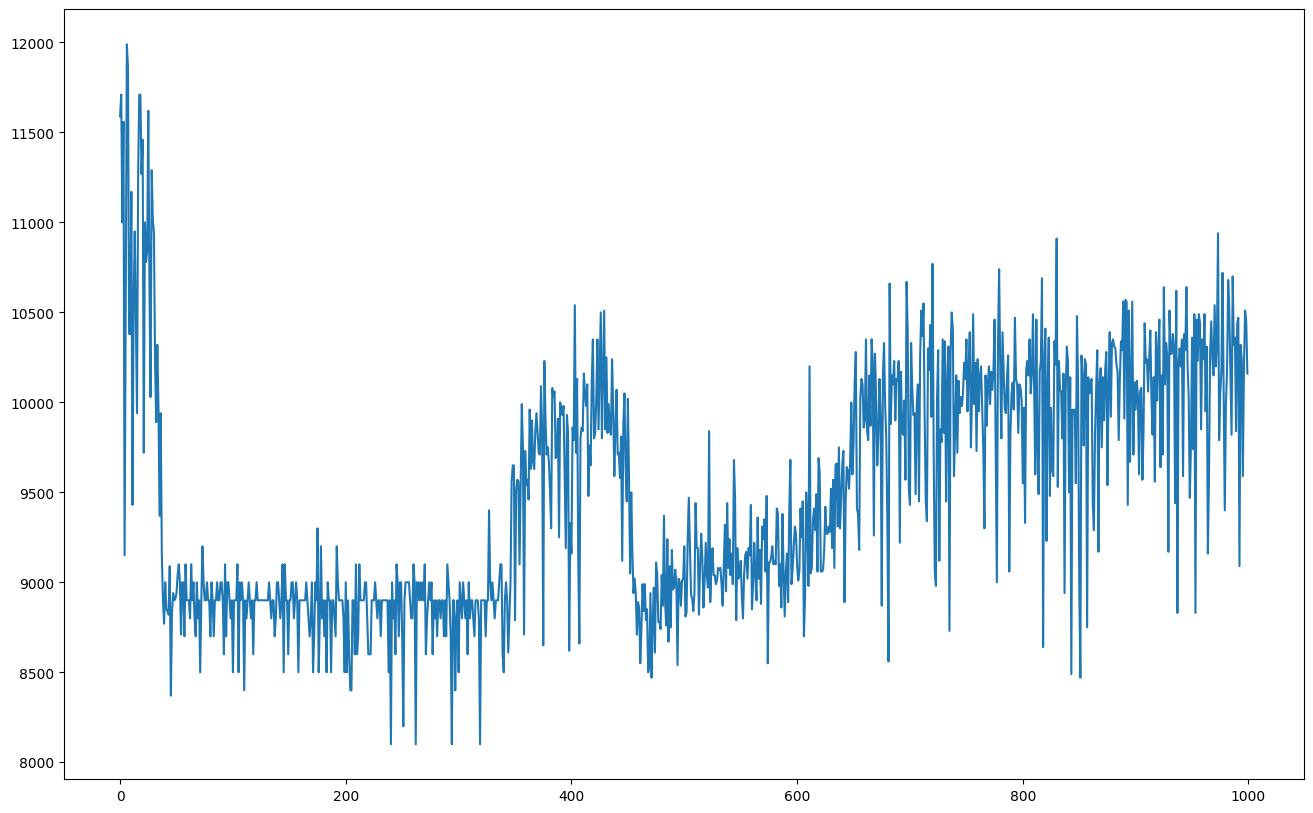

In [9]:
plt.figure(figsize=(16, 10))
plt.plot(range(len(total_reward_list)),
         total_reward_list)
plt.show()